## 🔵 Putting it all together:

1. Importing the Main Libraries
2. Set up device-agnostic code (later we send our model to this device)
3. Data
4. Splitting the data
5. Visualize it

**Second step: building or picking a model** 

6. Building a model
7. Set the manual seed
8. Make an instance of your model

**Third step: Training a Model**

9. Set the model AND data to use the target device we set in step 2.
10. Set up the loss function and optimizer
11. Training loop
12. Testing loop

**Fourth Step: Making Predictions with Trained Model**

13. Set the model to eval mode (since we are predicting)
14. Find y_preds using the trained model and X_test
15. Visualize it to see how good the predictions are now

**Fifth Step: Saving and Loading the Model**


16. from pathlib import Path 
17. Make a directory for our model (if we haven't already)
18. Make a MODEL_NAME
19. Make a MODEL_SAVE_PATH
20. Save the state_dict of the model (pass the obj=state_dict, f=MODEL_SAVE_PATH)

LOADING IT:

22. Make a new instance of the model using LinearRegressionModelV2()
23. For new insant load state dict by passing/loading the MODEL_SAVE_PATH
24. Put this new instant to device-agnostic code as well

EVALUATE THE LOADED MODEL:

25. Set the model to eval mode
26. Find y_preds_loaded using the loaded model and X_test
27. check y_preds == y_preds_loaded


#### 🟢 1. Importing Main Libraries

In [16]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# Chech the PyTorch version:
torch.__version__

'2.8.0'

Create device-agnostic code.

This means if we've got access to a GPU, our code will use it (for potentially faster computing)

If no GPU is available, the code will default to using a CPU. 

(For now, we have CPU only and to have GPU we have to either set it up locally or we have to use Google Colab)

#### 🟢 2. Set Up Device-Agnostic Code

In [17]:
# setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


#### 🟢 3. Data

In [18]:
# Create some data using the linear regression models formula:
weight = 0.3
bias = 0.1

# create the range:
start = 0
end = 1
step = 0.02 

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # need to not face error
y = weight * X + bias 

# testing our result:
print(X[:10])
print(y[:10])

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])
tensor([[0.1000],
        [0.1060],
        [0.1120],
        [0.1180],
        [0.1240],
        [0.1300],
        [0.1360],
        [0.1420],
        [0.1480],
        [0.1540]])


#### 🟢 4. Splitting the data

In [19]:
# split data:
train_split = int(0.8 * len(X)) # 80% of numbers of X
X_train = X[:train_split]
X_test = X[train_split:]

y_train_target = y[:train_split]
y_test_target = y[train_split:]

# testing our result:
print(f" X_train: {len(X_train)} X_test: {len(X_test)}") 
print(f" y_train_target: {len(y_train_target)} y_test_target: {len(y_test_target)}")

 X_train: 40 X_test: 10
 y_train_target: 40 y_test_target: 10


#### 🟢 5. Plot the Data:

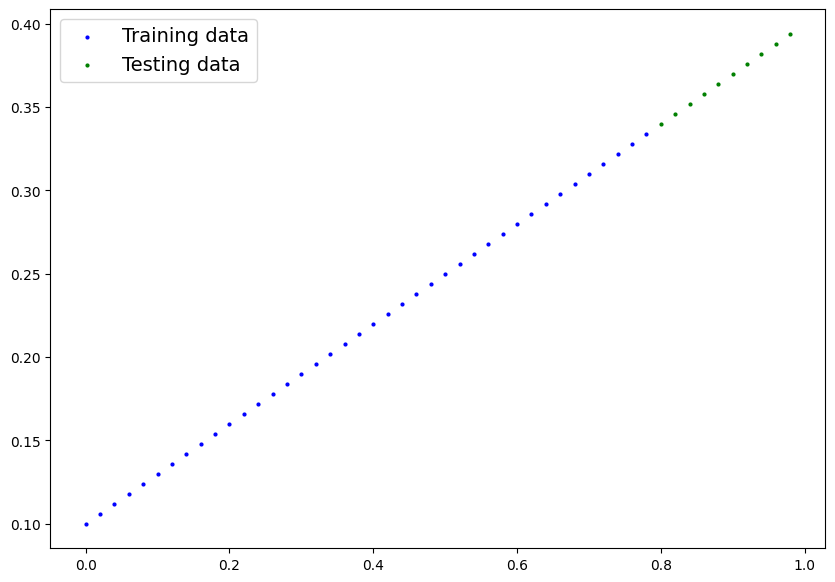

In [20]:
def plot_perdictions(train_data=X_train, 
                     train_labels=y_train_target, 
                     test_data=X_test, 
                     test_labels=y_test_target, 
                     perdictions=None):
    '''
        Plots training data, test data and compares predictions. 
    '''
    plt.figure(figsize=(10, 7))

    # Plot training data in blue:
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot testing data in blue:
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")


    # Are there perdictions?
    if perdictions is not None:
        # Plot the perdictions if they exist:

        plt.scatter(test_data, perdictions, c="r", s=4, label="Perdictions")

    # Show the legend:
    plt.legend(prop={"size":14})

    '''
    New Functions:
        1. Plotting the data as a graph:
            plt.scatter(input_data(x), output_data(y), color (c="b/r/g/y"), 
                        size (s=int), label="nameOfData")

        2. Plotting the data info (Training data, Testsing data, ...)
            plt.legend(prop={"size":int})
    '''

plot_perdictions(X_train, y_train_target, X_test, y_test_target)

### 🔵 Building or Choosing a Model

In [21]:
# Create a linear model by subclassing nn.Modeule

class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1, 
                                     out_features=1)

        # So behind the scenes, this thing is doing the linear regression model
        # formula, and it's choosing its parameter randomly.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

#### 🟢 6. Set the model to use the target device

In [22]:
# Check the model's current device:
next(model_1.parameters()).device

# Send it to the device
model_1.to(device)
X_train = X_train.to(device)
X_test = X_test.to(device)

y_train_target = y_train_target.to(device)
y_test_taget = y_test_target.to(device)

# Check again: (since we don't have GPU, this has not changed)
next(model_1.parameters()).device

device(type='cpu')

### 🔵 Training the Model

#### 🟢 7. Loss function and Optimizer + training/testing loop

In [23]:
## Loss function and Optimization
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_1.parameters(), 
                            lr=0.01)

In [24]:
## Storing the values for saving our progress:
torch.manual_seed(42)
epoch_count = []
loss_values = []
test_loss_values = []

## Training/Testing loop and required step:
# 1. forward pass
# 2. calc the loss
# 3. zero the gradients
# 4. find the gradients
# 5. update the paramters

epochs = 200
for epoch in range(epochs):
    model_1.train()
    y_preds = model_1(X_train)
    loss = loss_fn(y_preds, y_train_target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ## Testing loop:
    # In this step, since we are just testing, and we don't need to have
    # computations graph for optimization, we use the torch.infrence_mode()
    # because it skips computation graph, gradient tracking and more
    
    model_1.eval()
    with torch.inference_mode():
        y_preds_test = model_1(X_test)
        loss_test = loss_fn(y_preds_test, y_test_target) 

    ## Now we have to save our progress:
    if epoch % 15 == 0: 
        epoch_count.append(epoch)
        loss_values.append(loss.detach())
        test_loss_values.append(loss_test.detach())

        ## Printing the information and parameters: 
        # print(f"Epoch: {epoch} | loss: {loss} | test_loss:{loss_test}")

print(model_1.state_dict())

OrderedDict([('linear_layer.weight', tensor([[0.3091]])), ('linear_layer.bias', tensor([0.1040]))])


### 🔵 Making Predictions with Trained Model

Now that training is completely finished, what are the model's final predictions on the test data?
Assuming training worked well, the predictions after training should be much closer to the true targets than the predictions from the beginning of training.

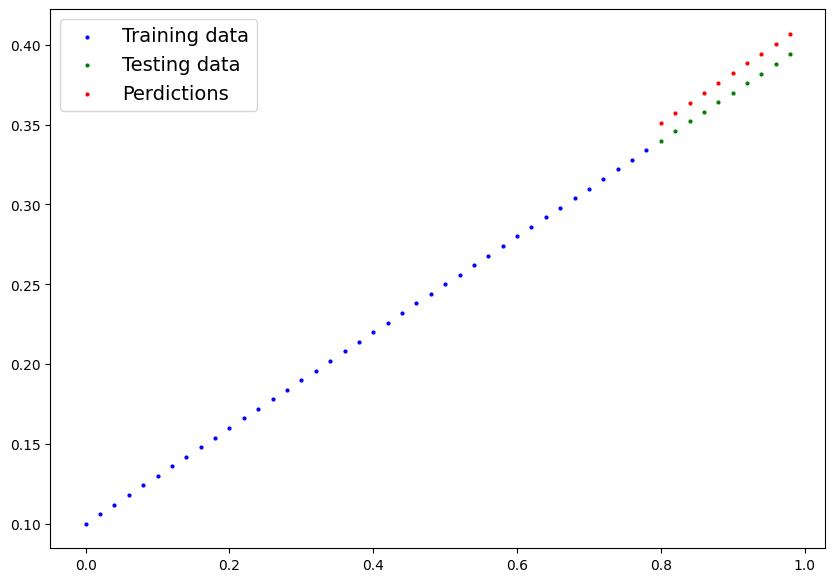

In [25]:
# Turn the model to evaluation mode:
model_1.eval()

# Make predictions on the test data +
# Turning on the inference mode when we make preds on test data
with torch.inference_mode():
    y_preds = model_1(X_test)

# Visualize:
# important Note::
# if the device is in GPU, we have to change the y_preds to CPU
# since for plotting we use matplotlib, and that uses CPU
plot_perdictions(perdictions=y_preds.cpu())


### 🔵 Saving and Loading the Model:

In [26]:
from pathlib import Path

## create the directory if we haven't had one:
MODEL_PATH = Path("models_linear_layer")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

## create a model save path
MODEL_NAME = "01_pytorch_workflow__model_1.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

## save the model dictionary
print(f"Saving the model to the path: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), 
          f=MODEL_SAVE_PATH)

Saving the model to the path: models_linear_layer/01_pytorch_workflow__model_1.pt


#### 🟢 Load the model:

In [27]:
## Load a PyTorch Model:
loaded_model_1 = LinearRegressionModelV2()

## Load the saved model_1 state dict 
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

## Put the loaded model to the device:
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

#### 🟢 Evaluate the loaded model:

In [28]:
loaded_model_1.eval()
with torch.inference_mode():
    y_preds_loaded = loaded_model_1(X_test)

y_preds_loaded == y_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])